# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import os
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [2]:
df = pd.read_csv('data/temps.csv')

### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [3]:
df.head()

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            348 non-null    int64  
 1   month           348 non-null    int64  
 2   day             348 non-null    int64  
 3   week            348 non-null    object 
 4   temp_2          348 non-null    int64  
 5   temp_1          348 non-null    int64  
 6   average         348 non-null    float64
 7   actual          348 non-null    int64  
 8   forecast_noaa   348 non-null    int64  
 9   forecast_acc    348 non-null    int64  
 10  forecast_under  348 non-null    int64  
 11  friend          348 non-null    int64  
dtypes: float64(1), int64(10), object(1)
memory usage: 32.8+ KB


In [5]:
df.describe()

,year,month,day,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,57.238506,62.373563,59.772989,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,10.605746,10.549381,10.705256,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,41.000000,46.000000,44.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,48.000000,53.000000,50.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,56.000000,61.000000,58.000000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,66.000000,72.000000,69.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,77.000000,82.000000,79.000000,95.000000


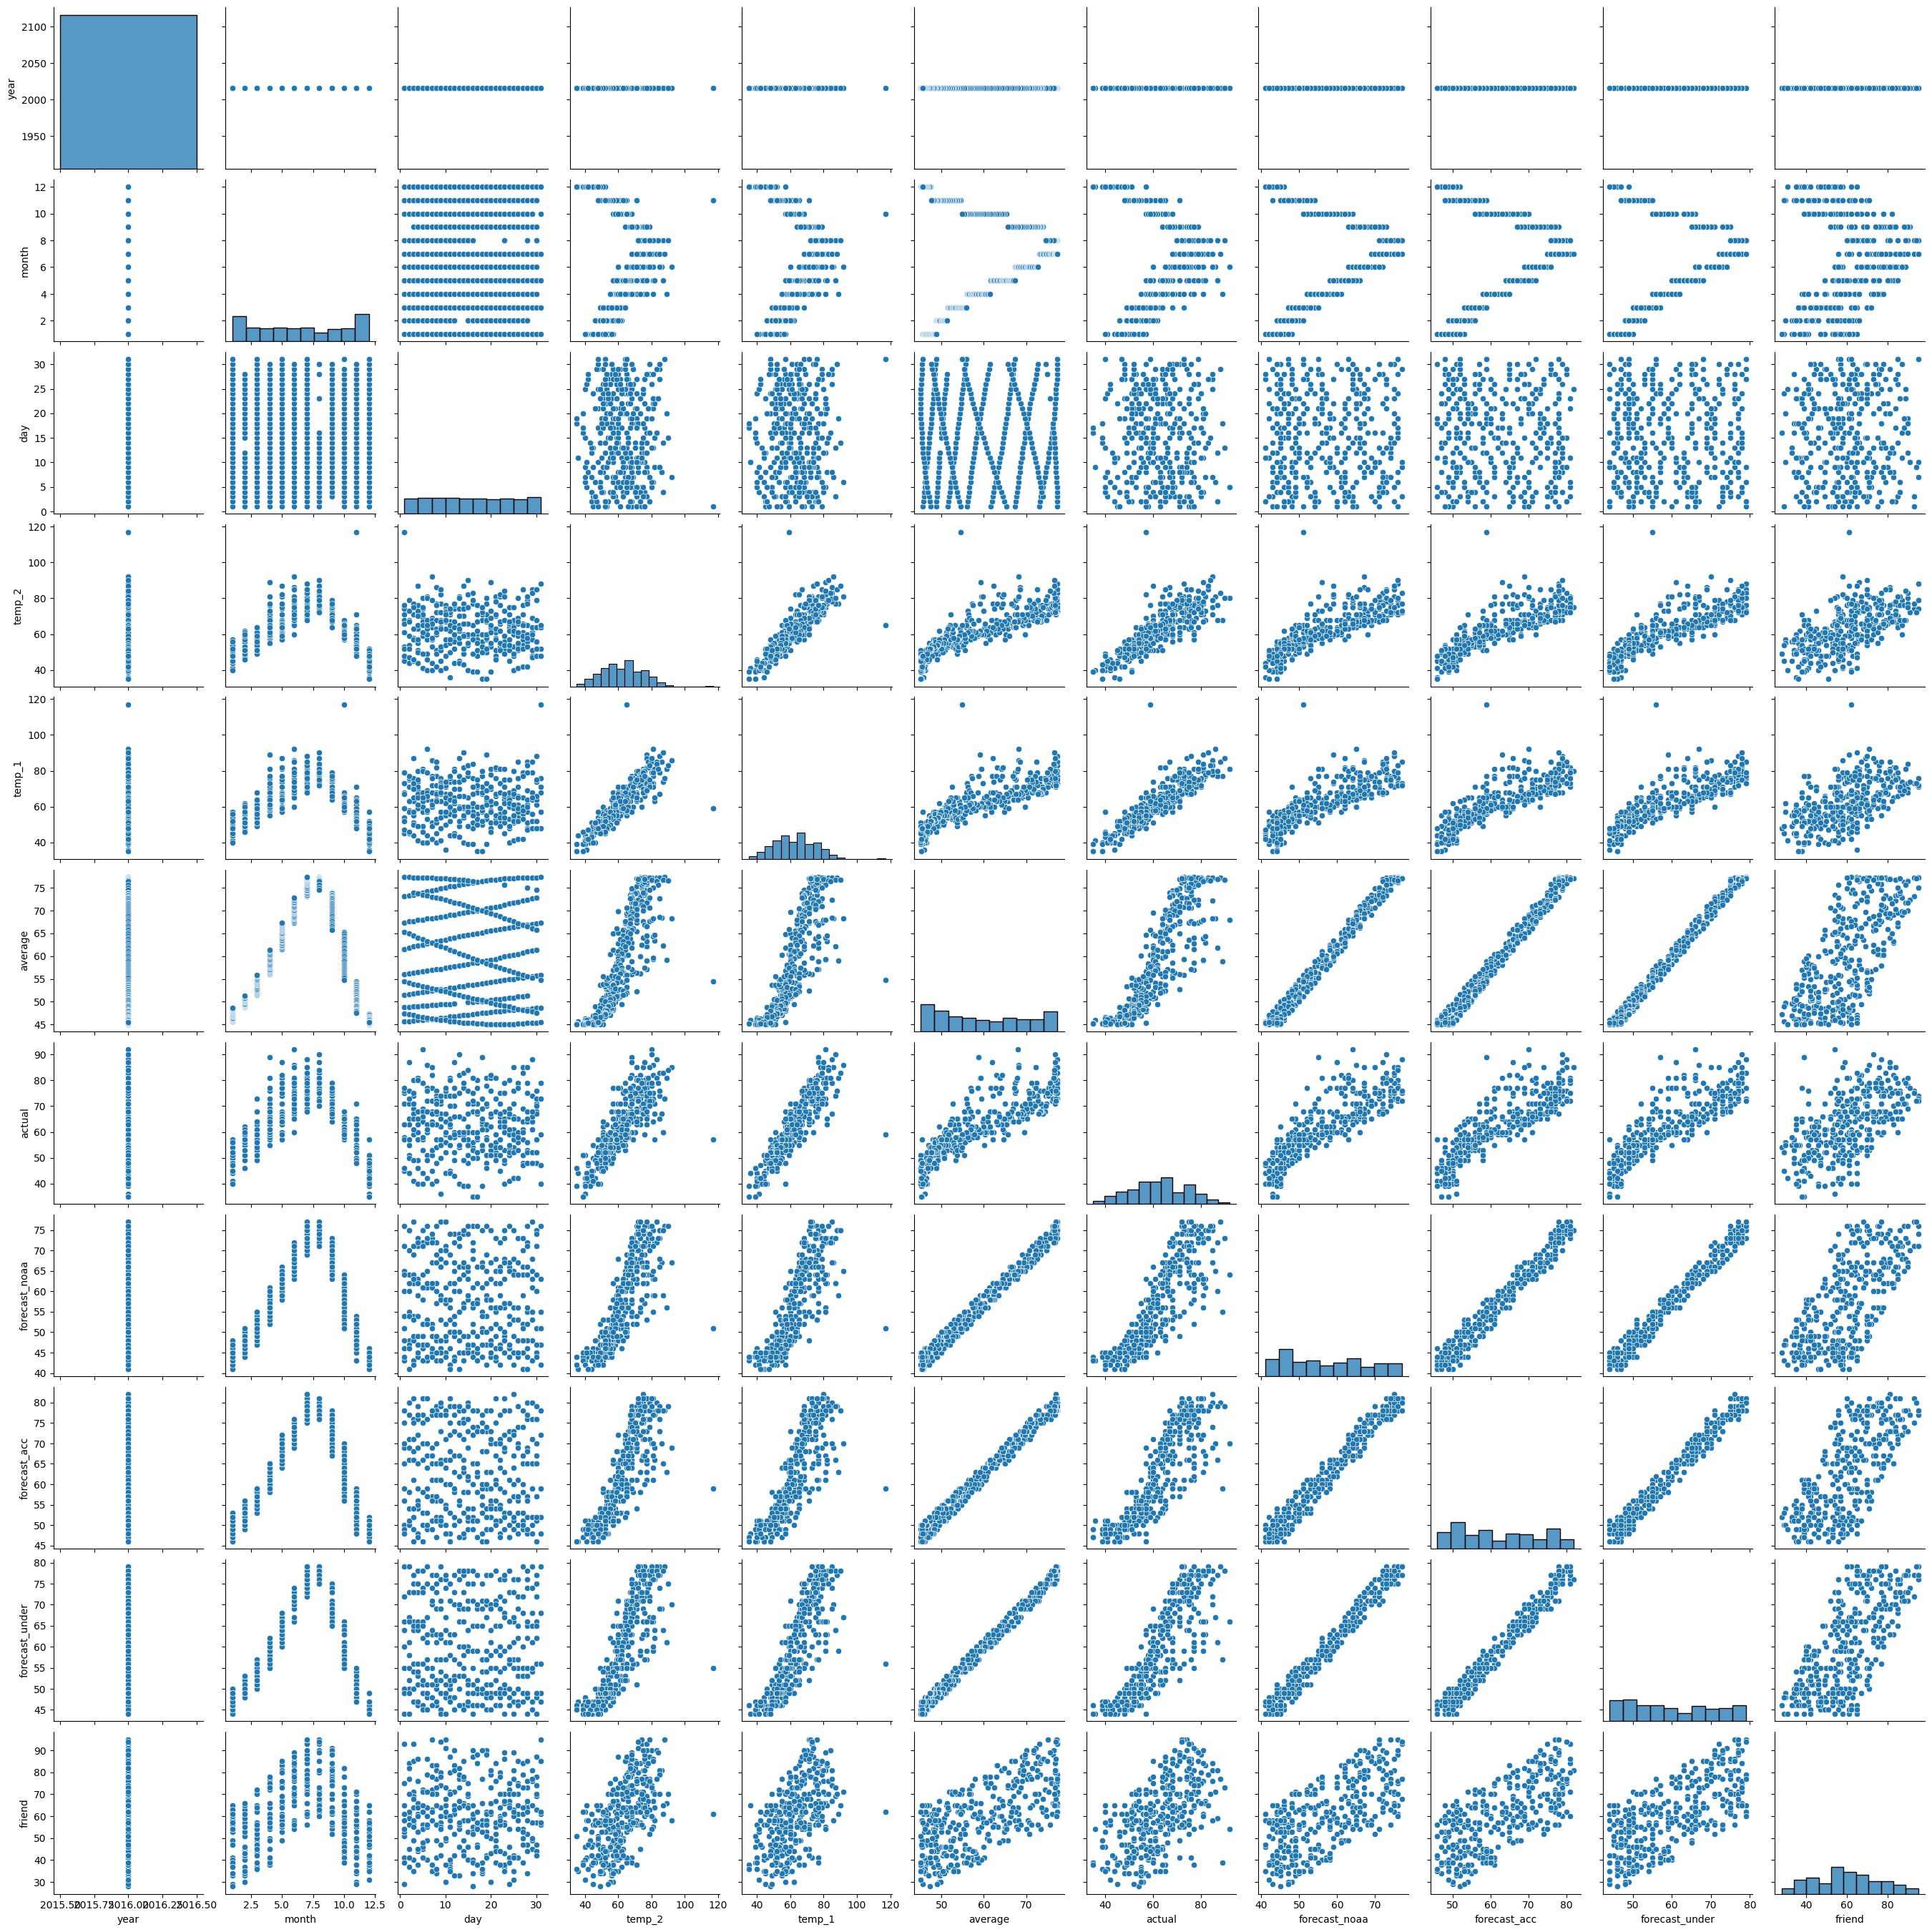

In [6]:
sns.pairplot(df);

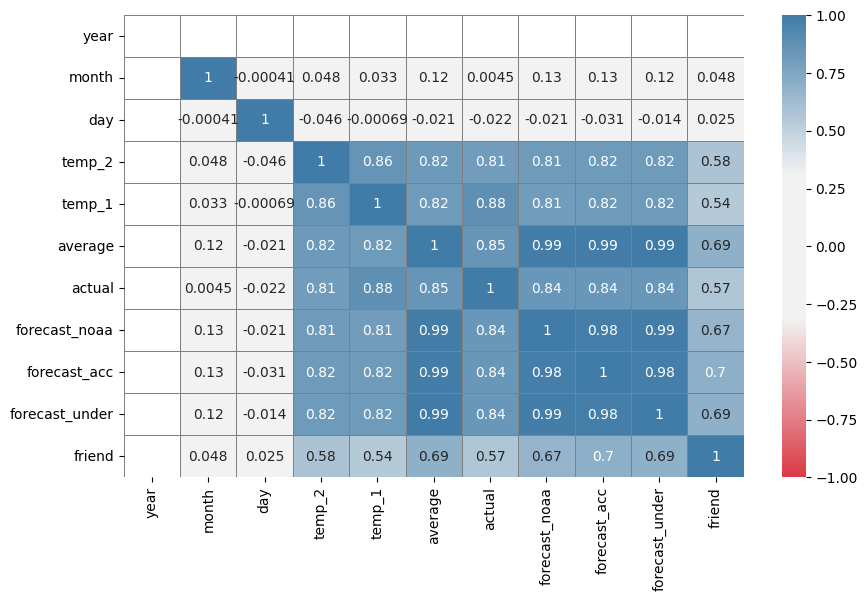

In [8]:
plt.figure(figsize=(10, 6))
cmap = sns.diverging_palette(10, 240, sep=80, as_cmap=True)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap=cmap, center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor="gray");

In [9]:
df['week'].nunique ()

7

In [10]:
df['week'].unique ()

array(['Fri', 'Sat', 'Sun', 'Mon', 'Tues', 'Wed', 'Thurs'], dtype=object)

In [11]:
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()
label.fit (df['week'])
df ['week_id'] = label.transform(df ['week'])
df


,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,week_id
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29,0
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61,2
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56,3
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53,1
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,41,50,47,47,5
344,2016,12,28,Wed,42,47,45.3,48,41,49,44,58,6
345,2016,12,29,Thurs,47,48,45.3,48,43,50,45,65,4
346,2016,12,30,Fri,48,48,45.4,57,44,46,44,42,0


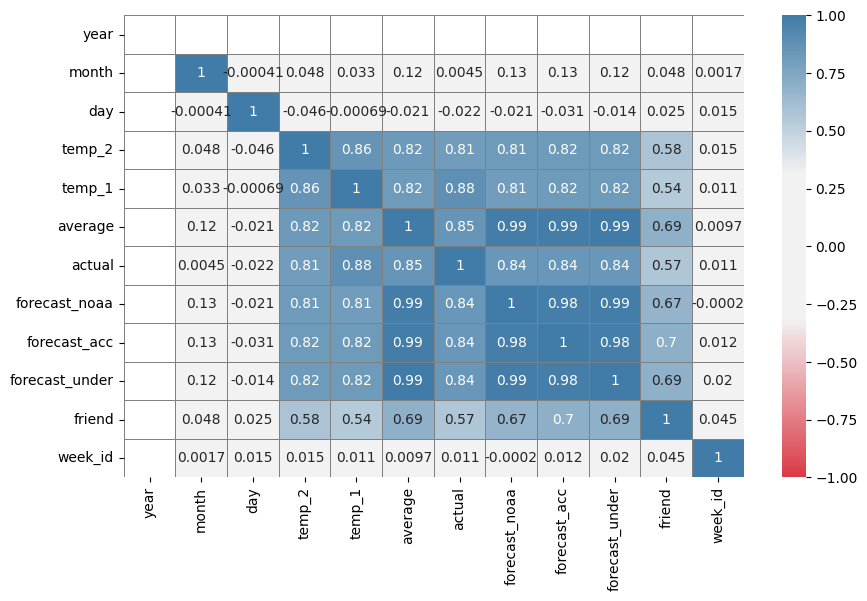

In [12]:
plt.figure(figsize=(10, 6))
cmap = sns.diverging_palette(10, 240, sep=80, as_cmap=True)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap=cmap, center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor="gray");

In [13]:
df ['Otoño'] = np.where (df['month'].isin([10,11,12]),1,0)
df ['Invierno'] = np.where (df['month'].isin([1,2,3]),1,0)
df ['Primavera'] = np.where (df['month'].isin([4,5,6]),1,0)
df ['Verano'] = np.where (df['month'].isin([7,8,9]),1,0)

In [14]:
df

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,week_id,Otoño,Invierno,Primavera,Verano
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29,0,0,1,0,0
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61,2,0,1,0,0
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56,3,0,1,0,0
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53,1,0,1,0,0
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41,5,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,41,50,47,47,5,1,0,0,0
344,2016,12,28,Wed,42,47,45.3,48,41,49,44,58,6,1,0,0,0
345,2016,12,29,Thurs,47,48,45.3,48,43,50,45,65,4,1,0,0,0
346,2016,12,30,Fri,48,48,45.4,57,44,46,44,42,0,1,0,0,0


In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            348 non-null    int64  
 1   month           348 non-null    int64  
 2   day             348 non-null    int64  
 3   week            348 non-null    object 
 4   temp_2          348 non-null    int64  
 5   temp_1          348 non-null    int64  
 6   average         348 non-null    float64
 7   actual          348 non-null    int64  
 8   forecast_noaa   348 non-null    int64  
 9   forecast_acc    348 non-null    int64  
 10  forecast_under  348 non-null    int64  
 11  friend          348 non-null    int64  
 12  week_id         348 non-null    int64  
 13  Otoño           348 non-null    int64  
 14  Invierno        348 non-null    int64  
 15  Primavera       348 non-null    int64  
 16  Verano          348 non-null    int64  
dtypes: float64(1), int64(15), object(1)

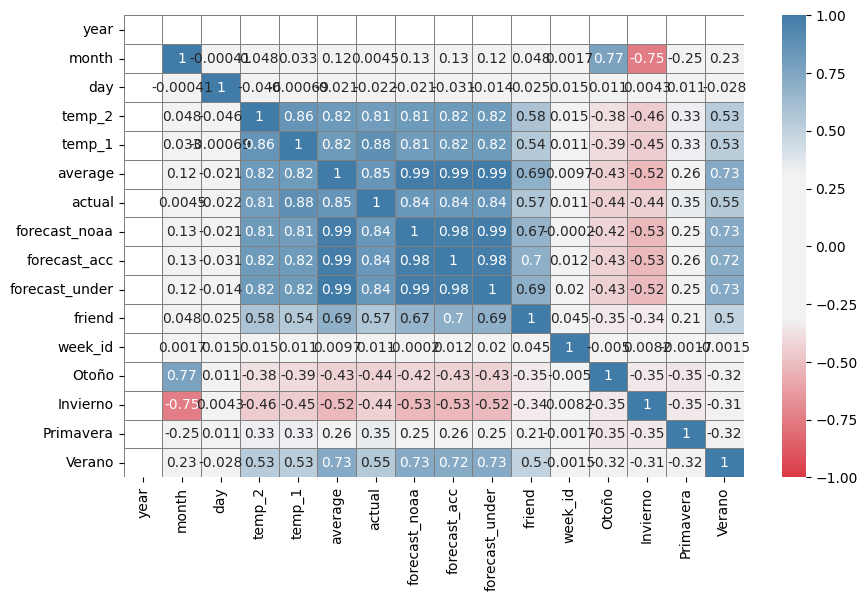

In [15]:
plt.figure(figsize=(10, 6))
cmap = sns.diverging_palette(10, 240, sep=80, as_cmap=True)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap=cmap, center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor="gray");

### 3. Selecciona variables y divide en train y test

# Me quedo con las columnas average, temp_1 y temp_2

In [16]:
X = df [['temp_2','temp_1','average']] 
y = df ['actual']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)

### 4. Entrena el modelo


# Modelo lineal

In [62]:
linear_modelo = LinearRegression()
linear_modelo.fit(X_train, y_train)

LinearRegression()

# Modelo polinomico

In [63]:
pol_modelo = PolynomialFeatures(degree = 4)
pol_modelo.fit(X_train)
X_train_poly = pol_modelo.transform(X_train)
X_test_poly = pol_modelo.transform(X_test)

pol_reg = LinearRegression()
pol_reg.fit(X_train_poly, y_train)

LinearRegression()

### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

In [64]:
pred_lin = linear_modelo.predict (X_test)

print('MAE:', metrics.mean_absolute_error(y_test, pred_lin))
print('MAPE', metrics.mean_absolute_percentage_error(y_test, pred_lin))
print('MSE:', metrics.mean_squared_error(y_test, pred_lin)) # BASELINE ERROR
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred_lin))) 
print('score train',linear_modelo.score(X_train, y_train))
print('score test',linear_modelo.score(X_test, y_test)) 

MAE: 3.6052416979048303
MAPE 0.05851236082775859
MSE: 22.110060335143885
RMSE: 4.702133593927749
score train 0.8085365554989355
score test 0.8599500299360308


In [65]:
pred_pol = pol_reg.predict(X_test_poly)

print('MAE:', metrics.mean_absolute_error(y_test, pred_pol))
print('MAPE', metrics.mean_absolute_percentage_error(y_test, pred_pol))
print('MSE:', metrics.mean_squared_error(y_test, pred_pol))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred_pol)))
print('score train',pol_reg.score(X_train_poly, y_train))
print('score test',pol_reg.score(X_test_poly, y_test))      

MAE: 64.25361506639959
MAPE 1.1195716387618566
MSE: 259491.8447974366
RMSE: 509.40342048069976
score train 0.8709976064179747
score test -1642.6782417079116


### 6. Representa el árbol de decisión

In [19]:
tree_reg_2 = DecisionTreeRegressor(max_depth=2, random_state=10)
tree_reg_2.fit(X, y)

DecisionTreeRegressor(max_depth=2, random_state=10)

In [24]:
pred_tree = tree_reg_2.predict(X)

print('MAE:', metrics.mean_absolute_error(y, pred_tree))
print('MAPE', metrics.mean_absolute_percentage_error(y, pred_tree))
print('MSE:', metrics.mean_squared_error(y, pred_tree))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y, pred_tree)))  

MAE: 4.236251271474959
MAPE 0.0687028889046704
MSE: 29.39829608194917
RMSE: 5.422019557503382


In [25]:
tree_reg_2.score (X,y)

0.7880473166029709

In [24]:
# X = df [['temp_2','temp_1','average']] 
# y = df ['actual']

In [26]:
tree_reg_2.predict([[45,44,45.8]])

c:\Users\amaci\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([43.825])

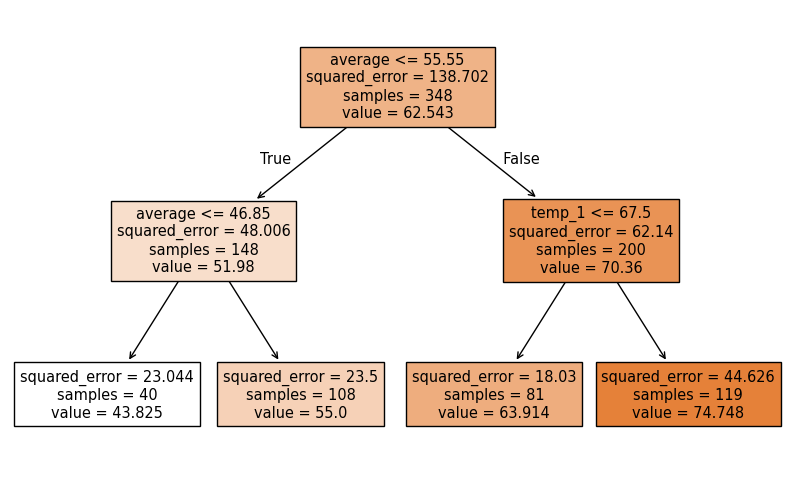

In [27]:
plt.figure(figsize=(10,6))
sklearn.tree.plot_tree(tree_reg_2, feature_names=X.columns, filled = True, ax=plt.gca());

### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [30]:
tree_reg_3 = DecisionTreeRegressor(max_depth=3, random_state=10)
tree_reg_3.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=10)

### 8. Vuelve a evaluar tu modelo

In [31]:
tree_reg_3.predict([[45,44,45.8]])

c:\Users\amaci\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([43.89285714])

In [32]:
pred_tree_1 = tree_reg_3.predict(X_test)

print('MAE:', metrics.mean_absolute_error(y_test, pred_tree_1))
print('MAPE', metrics.mean_absolute_percentage_error(y_test, pred_tree_1))
print('MSE:', metrics.mean_squared_error(y_test, pred_tree_1))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred_tree_1)))  

MAE: 3.8580140930831206
MAPE 0.06221658327719937
MSE: 24.413595441346715
RMSE: 4.941011580774398


### 9. Vuelve a representar su árbol

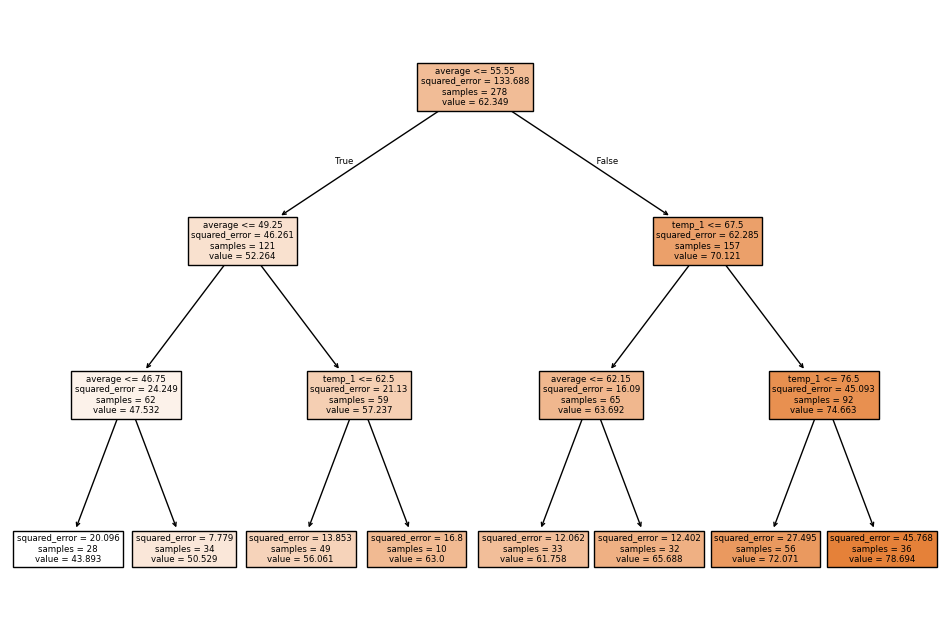

In [34]:
plt.figure(figsize=(12,8))
sklearn.tree.plot_tree(tree_reg_3, feature_names=X.columns, filled = True);

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

In [72]:
from sklearn import model_selection
name='Logistic Regression'
kfold = model_selection.KFold(n_splits=10) #Parte los datos en 10 trozos para usar validación cruzada / cross validation
cv_results = model_selection.cross_val_score(tree_reg_3, X_train, y_train, cv=kfold)

msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
print(cv_results)
print(msg)

[0.827013   0.76763288 0.85012717 0.80155921 0.77582649 0.88232041
 0.85747593 0.79381488 0.79683427 0.51049238]
Logistic Regression: 0.786310 (0.098461)


In [37]:
modelo = DecisionTreeRegressor (random_state=0)

### 11. Obten el `feature_importances` de cada variable en el último modelo

In [48]:
param_grid = {
    'max_depth': [3, 5],  # Profundidad máxima (None = sin límite)
    'min_samples_split': [2, 5, 10],     # Mínimo muestras para dividir un nodo
    'min_samples_leaf': [1, 2, 4],       # Mínimo muestras en hojas
    'max_features': ['sqrt'],    # Número de features para dividir
    'criterion': ['squared_error', 'absolute_error']  # Método de división
}

In [49]:
grid_search = GridSearchCV(
    estimator=modelo,
    param_grid = param_grid,
    cv=5,                       # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Métrica a optimizar (MSE negativo)
    n_jobs=-1,                  # Usa todos los núcleos del CPU
    verbose=1                   # Muestra progreso
)

In [50]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=0), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'absolute_error'],
                         'max_depth': [3, 5], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='neg_mean_squared_error', verbose=1)

In [53]:
grid_search.best_params_

{'criterion': 'squared_error',
 'max_depth': 5,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 10}

In [52]:
grid_search.best_estimator_

DecisionTreeRegressor(max_depth=5, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=10, random_state=0)

In [51]:
tree_reg_3_definitivo = DecisionTreeRegressor(max_depth=5, random_state=10)
tree_reg_3_definitivo.fit(X, y)

DecisionTreeRegressor(max_depth=5, random_state=10)

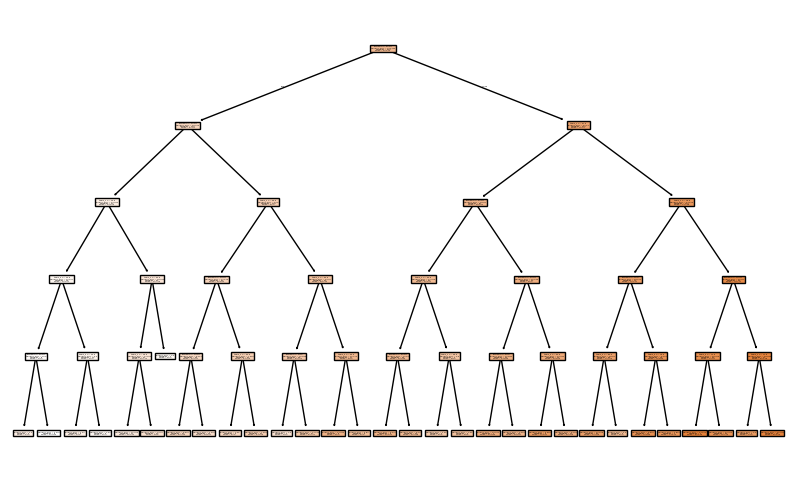

In [47]:
plt.figure(figsize=(10,6))
sklearn.tree.plot_tree(tree_reg_3_definitivo, feature_names=X.columns, filled = True, ax=plt.gca());

In [54]:
tree_reg_3_definitivo.feature_importances_

array([0.01412191, 0.19899439, 0.7868837 ])

### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC. ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [62]:
df['target_cl'] = np.where (df['actual']>59, 1, 0)

In [61]:
df

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,week_id,Otoño,Invierno,Primavera,Verano,target_cl
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29,0,0,1,0,0,0
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61,2,0,1,0,0,0
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56,3,0,1,0,0,0
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53,1,0,1,0,0,0
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41,5,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,41,50,47,47,5,1,0,0,0,0
344,2016,12,28,Wed,42,47,45.3,48,41,49,44,58,6,1,0,0,0,0
345,2016,12,29,Thurs,47,48,45.3,48,43,50,45,65,4,1,0,0,0,0
346,2016,12,30,Fri,48,48,45.4,57,44,46,44,42,0,1,0,0,0,0


In [63]:
df['target_cl'].value_counts(normalize = True)

target_cl
1    0.586207
0    0.413793
Name: proportion, dtype: float64

In [64]:
X = df [['temp_1','temp_2','average']]
y = df ['target_cl']

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [66]:
tree_clas_1 = DecisionTreeClassifier()

parametros = { 
    'max_depth': [2,3,4,5,6,7],
    'min_samples_leaf': [2,4,6,8]
}

gs_c = GridSearchCV (tree_clas_1, parametros, cv=6, scoring='accuracy', verbose=3)
gs_c.fit(X_train, y_train)

Fitting 6 folds for each of 24 candidates, totalling 144 fits
[CV 1/6] END ...max_depth=2, min_samples_leaf=2;, score=0.915 total time=   0.0s
[CV 2/6] END ...max_depth=2, min_samples_leaf=2;, score=0.851 total time=   0.0s
[CV 3/6] END ...max_depth=2, min_samples_leaf=2;, score=0.935 total time=   0.0s
[CV 4/6] END ...max_depth=2, min_samples_leaf=2;, score=0.913 total time=   0.0s
[CV 5/6] END ...max_depth=2, min_samples_leaf=2;, score=0.891 total time=   0.0s
[CV 6/6] END ...max_depth=2, min_samples_leaf=2;, score=0.913 total time=   0.0s
[CV 1/6] END ...max_depth=2, min_samples_leaf=4;, score=0.915 total time=   0.0s
[CV 2/6] END ...max_depth=2, min_samples_leaf=4;, score=0.851 total time=   0.0s
[CV 3/6] END ...max_depth=2, min_samples_leaf=4;, score=0.935 total time=   0.0s
[CV 4/6] END ...max_depth=2, min_samples_leaf=4;, score=0.913 total time=   0.0s
[CV 5/6] END ...max_depth=2, min_samples_leaf=4;, score=0.891 total time=   0.0s
[CV 6/6] END ...max_depth=2, min_samples_leaf=4

GridSearchCV(cv=6, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7],
                         'min_samples_leaf': [2, 4, 6, 8]},
             scoring='accuracy', verbose=3)

In [68]:
gs_c.best_params_

{'max_depth': 3, 'min_samples_leaf': 2}

In [69]:
gs_c.best_score_

np.float64(0.910114091890225)

In [70]:
gs_c.best_estimator_

DecisionTreeClassifier(max_depth=3, min_samples_leaf=2)

In [76]:
modelo_final = gs_c.best_estimator_

modelo_final.predict([[60,61,62.2]])

c:\Users\amaci\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

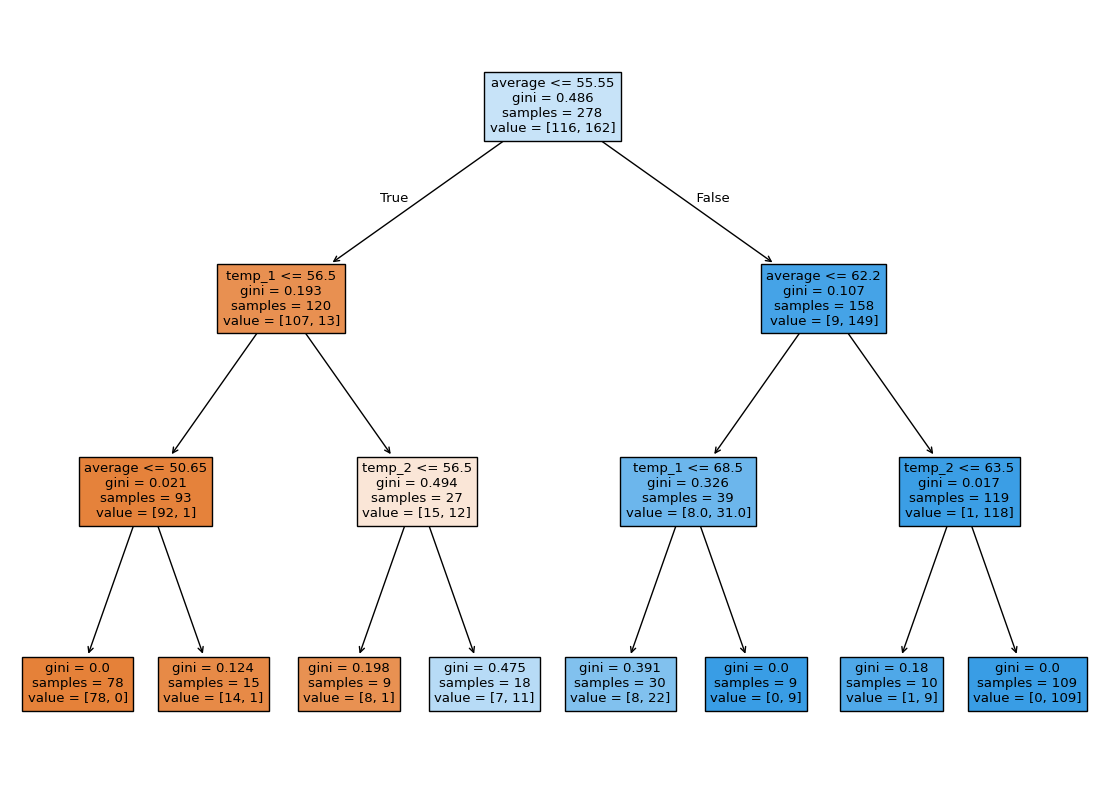

In [77]:
plt.figure(figsize=(14,10))
sklearn.tree.plot_tree(modelo_final, feature_names=X.columns, filled = True);

### 13. Construye un nuevo modelo `RandomForestClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC. ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.